# Introduction to ML — Geometry & Instance-based vs. Model-based Learning

This notebook is a from-scratch, visual demo of two ideas covered in `notes.md`:

1. The equation of a line/hyperplane in 2D and 3D, plotted directly.
2. A side-by-side comparison of **instance-based learning** (`KNeighborsClassifier`) vs. **model-based learning** (`LogisticRegression`) on the same small dataset, by looking at their decision boundaries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 5)


## 1) Equation of a line in 2D

A line in 2D can be written in vector form as $\mathbf{w}^T \mathbf{x} + b = 0$, i.e. $w_1 x + w_2 y + b = 0$.

Below we pick $\mathbf{w} = [2, -3]$ and $b = 6$, so the line is $2x - 3y + 6 = 0$, and plot it along with its normal vector $\mathbf{w}$.

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11322/635105618.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Line as $\mathbf{w}^T\mathbf{x} + b = 0$, with normal vector $\mathbf{w}$")


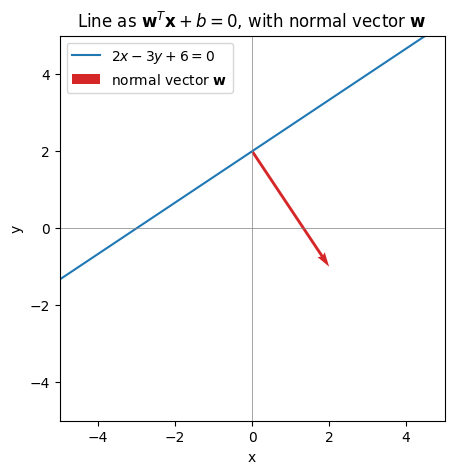

In [2]:
w = np.array([2.0, -3.0])
b = 6.0

x_vals = np.linspace(-5, 5, 200)
# solve for y: w1*x + w2*y + b = 0  =>  y = -(w1*x + b) / w2
y_vals = -(w[0] * x_vals + b) / w[1]

fig, ax = plt.subplots()
ax.plot(x_vals, y_vals, label=r"$2x - 3y + 6 = 0$", color="tab:blue")

# draw the normal vector w from a point on the line
x0 = 0.0
y0 = -(w[0] * x0 + b) / w[1]
ax.quiver(x0, y0, w[0], w[1], angles="xy", scale_units="xy", scale=1,
          color="tab:red", label=r"normal vector $\mathbf{w}$")

ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Line as $\mathbf{w}^T\mathbf{x} + b = 0$, with normal vector $\mathbf{w}$")
ax.legend()
plt.show()


## 2) Equation of a plane / hyperplane in 3D

In 3D, the same idea generalizes to a plane $\mathbf{w}^T\mathbf{x} + b = 0$, i.e. $w_1 x + w_2 y + w_3 z + b = 0$.

We pick $\mathbf{w} = [1, 1, 2]$, $b = -4$, so the plane is $x + y + 2z - 4 = 0$, and solve for $z$ to plot a surface.

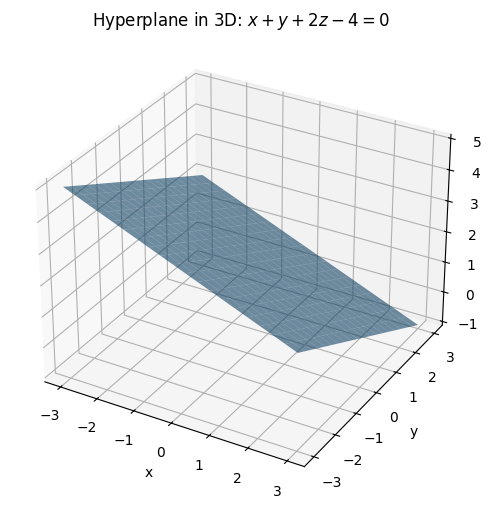

In [3]:
w3 = np.array([1.0, 1.0, 2.0])
b3 = -4.0

xx, yy = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
# solve for z: w1*x + w2*y + w3*z + b = 0 => z = -(w1*x + w2*y + b) / w3
zz = -(w3[0] * xx + w3[1] * yy + b3) / w3[2]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xx, yy, zz, alpha=0.6, color="tab:blue")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(r"Hyperplane in 3D: $x + y + 2z - 4 = 0$")
plt.show()


## 3) Instance-based vs. Model-based learning: decision boundaries

Now the practical comparison. We use `load_iris` restricted to **2 features** (so decision boundaries can be plotted in 2D) and 2 classes' worth of geometry visualized across all 3 classes.

- **Instance-based (lazy) learner:** `KNeighborsClassifier` — stores the training data and classifies a new point by majority vote among its nearest neighbors. No global model is fit; the boundary is determined locally.
- **Model-based (eager) learner:** `LogisticRegression` — fits a compact set of parameters ($\mathbf{w}, b$ per class) that define linear decision boundaries directly.

In [4]:
iris = load_iris()
X = iris.data[:, :2]  # sepal length, sepal width
y = iris.target
feature_names = iris.feature_names[:2]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X, y)

print(f"KNN training accuracy:        {knn.score(X, y):.3f}")
print(f"LogisticRegression accuracy:  {logreg.score(X, y):.3f}")


KNN training accuracy:        0.840
LogisticRegression accuracy:  0.820


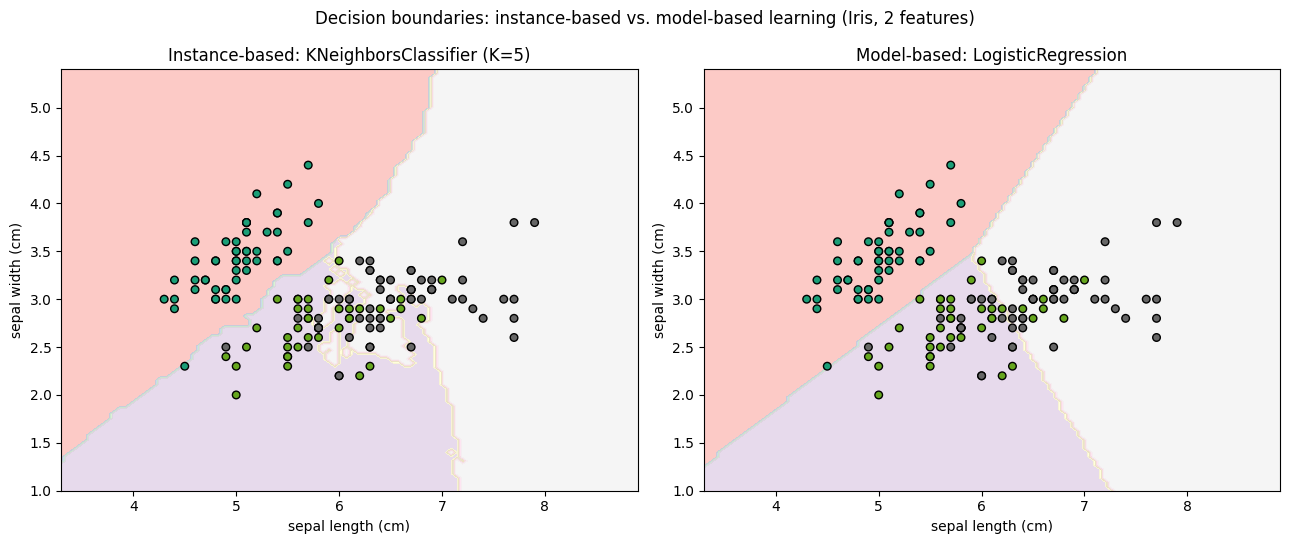

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, model, title in zip(
    axes,
    [knn, logreg],
    ["Instance-based: KNeighborsClassifier (K=5)", "Model-based: LogisticRegression"],
):
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method="predict", cmap="Pastel1", alpha=0.7, ax=ax,
        xlabel=feature_names[0], ylabel=feature_names[1],
    )
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="Dark2", edgecolor="k", s=30)
    ax.set_title(title)

fig.suptitle("Decision boundaries: instance-based vs. model-based learning (Iris, 2 features)")
plt.tight_layout()
plt.show()


## Takeaway

- The **KNN** boundary is jagged/local — it follows the density of nearby training points rather than a global mathematical form. Its "model" *is* the training data itself.
- The **Logistic Regression** boundary is smooth and (piecewise) linear — a compact set of weights defines straight-line boundaries between each pair of classes, learned once during training.

This mirrors the theoretical comparison in `notes.md`: instance-based learning defers work to prediction time and generalizes locally, while model-based learning does the work upfront and generalizes globally through a small set of learned parameters.